# CSCI 347 Final Project

Bailey Binando, Caitlin Hermanson, Lilly Pates

In [3]:
# load libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import seaborn as sns

In [2]:
%cd ~/Documents/Github/CSCI_347_Final_Project

/Users/lillypates/Documents/GitHub/CSCI_347_Final_Project


In [6]:
# load libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import seaborn as sns

,window_id,center_date,window_start,window_end,window_n_days,is_flood_event,n_flood_days_in_window,days_to_nearest_flood_in_window,flow_raw_max,flow_raw_mean,...,storm_wind_mean,RH2M_max,RH2M_mean,WS2M_max,WS2M_mean,storm_max_wind_kt_max,storm_max_wind_kt_mean,rp_for_impact,impact_proxy,impact_proxy_log
0,W000001,1975-01-04,1975-01-02,1975-01-06,5,0,0,NaN,50.0305,36.84938,...,0.0,NaN,NaN,NaN,NaN,0,0.0,3.198489,29791.041222,10.301997
1,W000002,1975-01-05,1975-01-03,1975-01-07,5,0,0,NaN,45.3183,34.26694,...,0.0,NaN,NaN,NaN,NaN,0,0.0,2.891200,28186.746623,10.246643
2,W000003,1975-01-06,1975-01-04,1975-01-08,5,0,0,NaN,45.3183,37.87166,...,0.0,NaN,NaN,NaN,NaN,0,0.0,2.891200,28186.746623,10.246643
3,W000004,1975-01-07,1975-01-05,1975-01-09,5,0,0,NaN,45.3183,38.02028,...,0.0,NaN,NaN,NaN,NaN,0,0.0,2.891200,28186.746623,10.246643
4,W000005,1975-01-08,1975-01-06,1975-01-10,5,0,0,NaN,42.1990,34.75174,...,0.0,NaN,NaN,NaN,NaN,0,0.0,2.692491,27107.964132,10.207620


## Feature Selection

In [7]:
%cd ~/Documents/Github/CSCI_347_Final_Project

impact_proxy_log                   1.000000
impact_proxy                       1.000000
rp_for_impact                      1.000000
rp_approx_max                      0.999928
flow_raw_max                       0.979499
flow_pct_max                       0.979499
max_exceedance_90                  0.979042
api_k_0_70_max                     0.964886
rain_2day_max                      0.936105
rain_3day_max                      0.919006
rp_approx_mean                     0.907794
api_k_0_80_max                     0.907667
rain_4day_max                      0.879679
tp_12h_intensity_mm_hr_max         0.868475
rain_1day_max                      0.863400
flow_raw_mean                      0.862610
api_k_0_85_max                     0.854213
rain_3day_mean                     0.852236
rain_2day_mean                     0.849658
tp_12h_intensity_mm_hr_mean        0.844644
api_k_0_70_mean                    0.832216
rain_5day_max                      0.826415
rain_4day_mean                  

In [8]:
# load data
df = pd.read_csv("data/master_full_rolling_5day_features.csv")
df.head()  # glimpse at structure: each row is a 5-day window

                 variable1                       variable2     corr
              impact_proxy                impact_proxy_log 1.000000
              flow_raw_max                    flow_pct_max 1.000000
           storm_wind_mean          storm_max_wind_kt_mean 1.000000
            storm_wind_max           storm_max_wind_kt_max 1.000000
             rp_for_impact                    impact_proxy 1.000000
             rp_for_impact                impact_proxy_log 1.000000
             rp_approx_max                    impact_proxy 0.999928
             rp_approx_max                   rp_for_impact 0.999928
             rp_approx_max                impact_proxy_log 0.999928
              flow_pct_max               max_exceedance_90 0.999436
              flow_raw_max               max_exceedance_90 0.999436
            rain_4day_mean                 api_k_0_70_mean 0.987587
           api_k_0_80_mean                 api_k_0_85_mean 0.986692
            api_k_0_80_max                  api_

In [9]:
# create month variable for future handling of missing values
df["month"] = pd.to_datetime(df["center_date"]).dt.month

# remove label/redundant analysis cols.
drop_cols = [
    "window_id", "center_date", "window_start", "window_end",
    "is_flood_event", "n_flood_days_in_window", "days_to_peak_flow",
    "days_to_nearest_flood_in_window", 'flow_raw_max',
    "impact_proxy", "impact_proxy_log", "rp_for_impact", 'rp_approx_max', 'rp_approx_mean',
    "window_n_days", "flow_raw_mean", "flow_pct_mean", "storm_wind_mean",
    "WS2M_mean", "RH2M_mean", 'api_k_0_70_max', 'api_k_0_70_mean', 'api_k_0_80_max',
    'api_k_0_80_mean', 'api_k_0_85_max', 'api_k_0_85_mean',
    "api_k_0_95_max", "api_k_0_95_mean", 'rain_1day_max', 'rain_1day_mean', 
    'rain_2day_max', 'rain_2day_mean', 'rain_4day_mean', 'rain_5day_max', 'rain_5day_mean', 'rain_7day_max',
    'rain_7day_mean', 'rain_14day_max', 'rain_14day_mean', 'tp_6h_intensity_mm_hr_mean',
    'tp_12h_intensity_mm_hr_max', 'tp_12h_intensity_mm_hr_mean', 'storm_max_wind_kt_max',
    'storm_max_wind_kt_mean', 'storm_within_300km', 'storm_within_500km', 'storm_wind_max',
    'max_exceedance_90', 'rain_4day_max', 'api_k_0_90_mean', 'rain_3day_mean'
]

feature_selection_final = df.drop(columns = drop_cols)

feature_selection_final.head()

,flow_pct_max,duration_above_90,area_above_90,rain_3day_max,tp_6h_intensity_mm_hr_max,api_k_0_90_max,storm_min_distance_km,RH2M_max,WS2M_max,month
0,0.687352,0,0.0,17.949861,1.387644,17.184730,NaN,NaN,NaN,1
1,0.654123,0,0.0,17.949861,1.387644,17.184730,NaN,NaN,NaN,1
2,0.654123,0,0.0,17.949861,1.387644,17.184730,NaN,NaN,NaN,1
3,0.654123,0,0.0,15.450961,0.169324,15.573230,NaN,NaN,NaN,1
4,0.628597,0,0.0,13.050195,0.169324,14.315296,NaN,NaN,NaN,1


## Preprocessing

In [10]:
# Spearman correlation with impact_proxy to rank feature relevance
# Using Spearman (rank-based) because the relationship may not be linear
num_df = df.select_dtypes(include = [np.number]).copy()

# drop rows with missing values for stable correlations
num_df = num_df.dropna()

corr_to_impact = (
    num_df.corr(method="spearman")["impact_proxy"].sort_values(ascending = False)
)

print(corr_to_impact)

flow_pct_max                     0
duration_above_90                0
area_above_90                    0
rain_3day_max                    0
tp_6h_intensity_mm_hr_max        0
api_k_0_90_max                   0
storm_min_distance_km        12994
RH2M_max                      2187
WS2M_max                      2187
month                            0
dtype: int64

In [11]:
# Identify highly correlated feature pairs (|r| > 0.85)
# to avoid redundancy in the feature set
num_df = df.select_dtypes(include=[np.number]).dropna()
corr = num_df.corr(method="spearman")

# upper triangle only to avoid duplicate pairs
upper = corr.abs().where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = upper.stack().reset_index()
high_corr.columns = ["variable1", "variable2", "corr"]

high_corr = high_corr[high_corr["corr"] > 0.85]

high_corr = high_corr.sort_values("corr", ascending=False)

print(high_corr.to_string(index=False))

flow_pct_max                 0
duration_above_90            0
area_above_90                0
rain_3day_max                0
tp_6h_intensity_mm_hr_max    0
api_k_0_90_max               0
storm_min_distance_km        0
RH2M_max                     0
WS2M_max                     0
no_storm                     0
dtype: int64

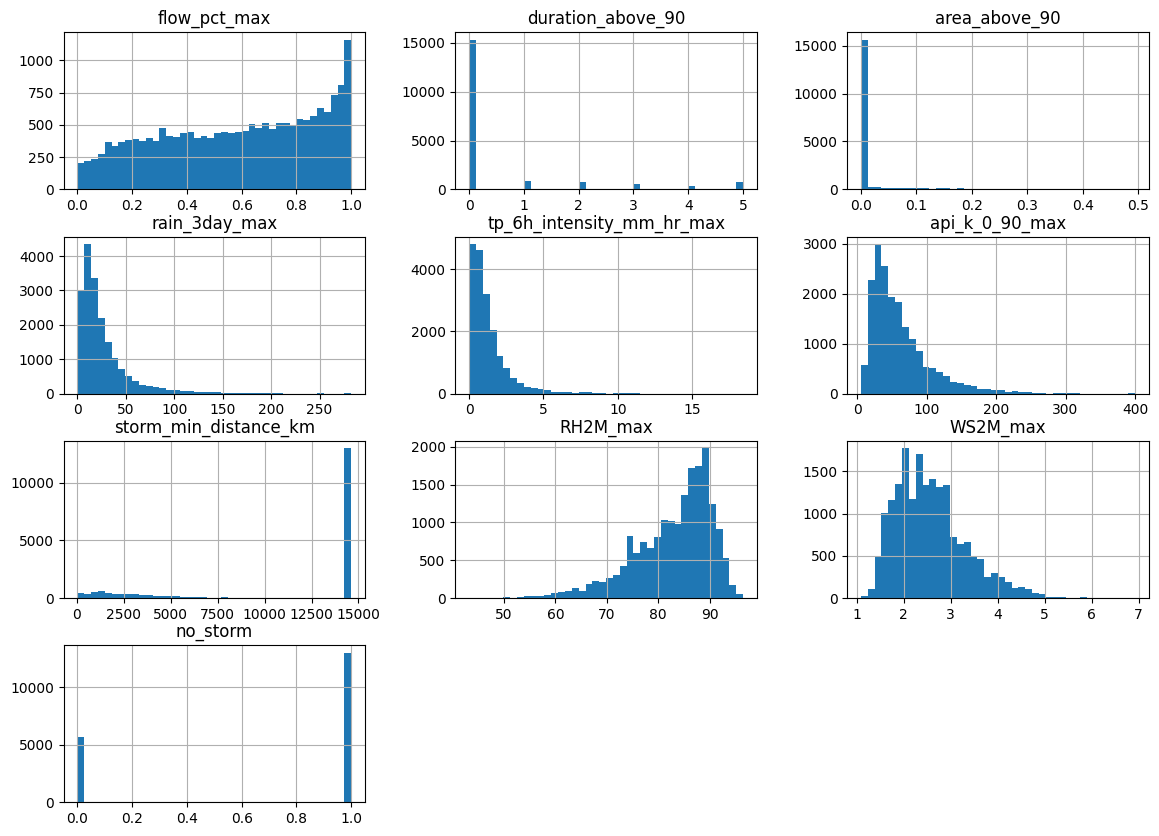

,flow_pct_max,duration_above_90,area_above_90,rain_3day_max,tp_6h_intensity_mm_hr_max,api_k_0_90_max,storm_min_distance_km,RH2M_max,WS2M_max
0,0.687352,0,0.0,2.941797,0.870307,2.900582,14616.956048,86.55,2.76
1,0.654123,0,0.0,2.941797,0.870307,2.900582,14616.956048,86.55,2.76
2,0.654123,0,0.0,2.941797,0.870307,2.900582,14616.956048,86.55,2.76
3,0.654123,0,0.0,2.800384,0.156425,2.807789,14616.956048,86.55,2.76
4,0.628597,0,0.0,2.642636,0.156425,2.728852,14616.956048,86.55,2.76


In [12]:
# extract month for seasonal imputation later
df["month"] = pd.to_datetime(df["center_date"]).dt.month

# drop label, redundant, and highly correlated columns identified above
# keeping one representative from each correlated group
drop_cols = [
    "window_id", "center_date", "window_start", "window_end",
    "is_flood_event", "n_flood_days_in_window", "days_to_peak_flow",
    "days_to_nearest_flood_in_window", 'flow_raw_max',
    "impact_proxy", "impact_proxy_log", "rp_for_impact", 'rp_approx_max', 'rp_approx_mean',
    "window_n_days", "flow_raw_mean", "flow_pct_mean", "storm_wind_mean",
    "WS2M_mean", "RH2M_mean", 'api_k_0_70_max', 'api_k_0_70_mean', 'api_k_0_80_max',
    'api_k_0_80_mean', 'api_k_0_85_max', 'api_k_0_85_mean',
    "api_k_0_95_max", "api_k_0_95_mean", 'rain_1day_max', 'rain_1day_mean',
    'rain_2day_max', 'rain_2day_mean', 'rain_4day_mean', 'rain_5day_max', 'rain_5day_mean', 'rain_7day_max',
    'rain_7day_mean', 'rain_14day_max', 'rain_14day_mean', 'tp_6h_intensity_mm_hr_mean',
    'tp_12h_intensity_mm_hr_max', 'tp_12h_intensity_mm_hr_mean', 'storm_max_wind_kt_max',
    'storm_max_wind_kt_mean', 'storm_within_300km', 'storm_within_500km', 'storm_wind_max',
    'max_exceedance_90', 'rain_4day_max', 'api_k_0_90_mean', 'rain_3day_mean'
]

feature_selection_final = df.drop(columns = drop_cols)

feature_selection_final.head()

## Analysis

### PCA

In [13]:
# standardize
scaler = StandardScaler()   
D_scaled = scaler.fit_transform(D)

# pca on normalized
pca_D_scaled = PCA() 
pca_transformed_D_scaled = pca_D_scaled.fit_transform(D_scaled)

# store component variance
explained_var = pca_D_scaled.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

In [14]:
# check for remaining missing values before imputation
feature_selection_final.isna().sum()

In order to capture at least 90% of the variance, 5 principal components are needed.


In [15]:
# FILL MISSING VALUES
D_raw = feature_selection_final.copy()

# fill missing meteorological values with monthly median
# NASA data starts in 1981, so earlier rows are NaN
# monthly median preserves seasonality (wet vs. dry season patterns)
met_cols = [
    "RH2M_max", "WS2M_max"
]
for col in met_cols:
    D_raw[col] = D_raw[col].fillna(D_raw.groupby("month")[col].transform("median"))

# remove month col. (no longer needed after imputation)
D_raw = D_raw.drop(columns = "month")

# storm distance is NaN when no storm was present in the Atlantic
# fill with max distance + buffer to treat "no storm" as very far away
max_distance = D_raw["storm_min_distance_km"].max()
buffer = max_distance + 1000
D_raw["storm_min_distance_km"] = D_raw["storm_min_distance_km"].fillna(buffer)
D_raw["no_storm"] = (D_raw["storm_min_distance_km"] > max_distance).astype(int)  # binary storm flag

D_raw.isna().sum()

The fraction of variance captured by PC1 and PC2 is 0.6889.


In [16]:
# TRANSFORMATIONS

# inspect distributions to spot skew before PCA
# PCA is sensitive to scale and skew; log-transforming right-skewed features
# brings them closer to normal and prevents them from dominating components
D_raw.hist(figsize = (14, 10), bins = 40)
plt.show()

D = D_raw.copy()

# log1p (log(x+1)) handles zeros without producing -inf
D["rain_3day_max"] = np.log1p(D["rain_3day_max"])
D["tp_6h_intensity_mm_hr_max"] = np.log1p(D["tp_6h_intensity_mm_hr_max"])
D["api_k_0_90_max"] = np.log1p(D["api_k_0_90_max"])
D["area_above_90"] = np.log1p(D["area_above_90"])
D = D.drop(columns = "no_storm")  # drop binary flag; not a continuous feature for PCA
D.head()

[0.53507213 0.15380512 0.09941002 0.07484773 0.06917547 0.03923456
 0.01669946 0.00732203 0.00443348]


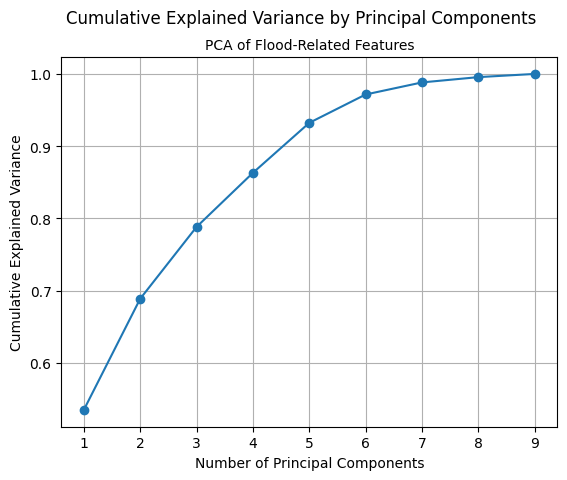

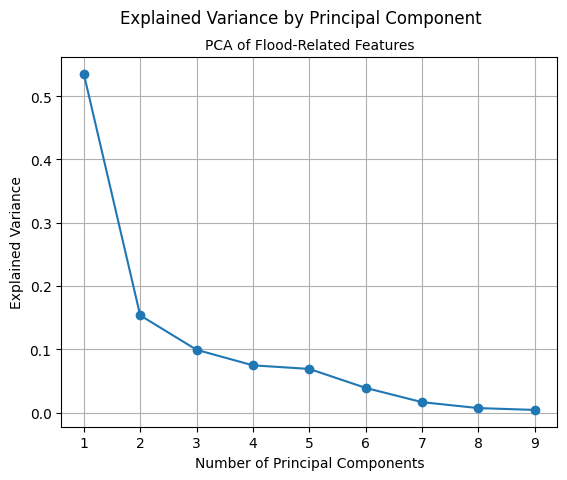

In [17]:
# PLOT CAPTURED VARIANCE FIGURES

# X axis: number of components (1 to n)
components = np.arange(1, len(cumulative_var) + 1)

# Plot
plt.plot(components, cumulative_var, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title("PCA of Flood-Related Features", fontsize = 10)
plt.suptitle('Cumulative Explained Variance by Principal Components')
plt.grid() # add gridlines

# Plot
plt.show()
plt.plot(components, explained_var, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance')
plt.suptitle('Explained Variance by Principal Component')
plt.title("PCA of Flood-Related Features", fontsize = 10)
plt.grid() # add gridlines

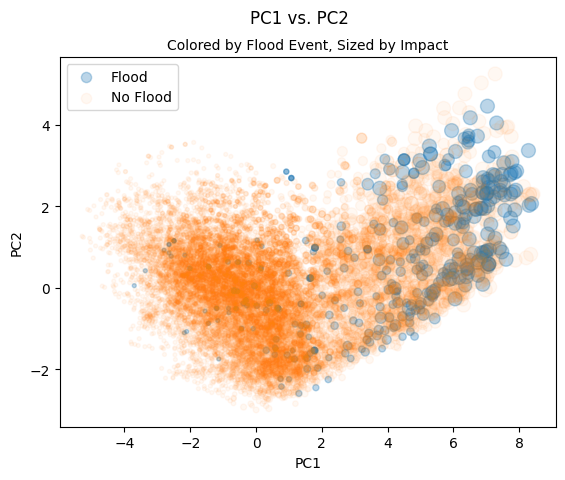

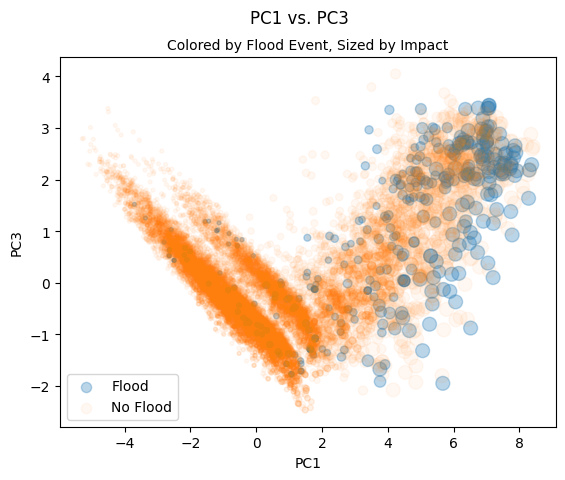

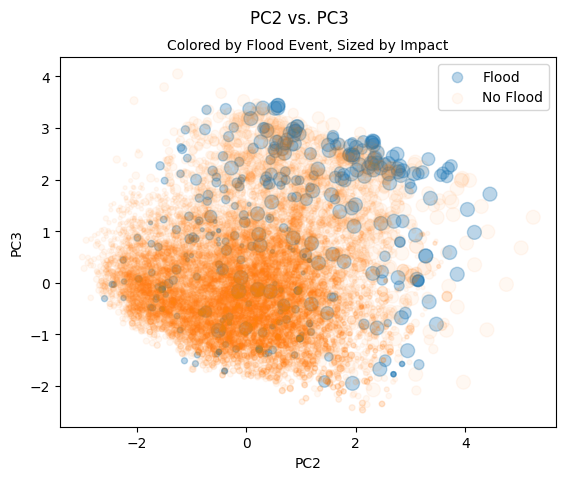

In [18]:
# PLOT PCA COMPONENTS
plot_df = D.copy()

# get label cols
plot_df["no_storm"] = D_raw["no_storm"].values
plot_df["is_flood_event"] = df["is_flood_event"]
plot_df["impact_proxy"] = df["impact_proxy"]
sizes = (plot_df["impact_proxy"] / plot_df["impact_proxy"].max()) * 100 # normalize for extreme impacts

flood = plot_df["is_flood_event"] == 1 # color by flood/non-flood event
no_flood = plot_df["is_flood_event"] == 0

# PC1 vs. PC2
plt.scatter(pca_transformed_D_scaled[flood, 0], pca_transformed_D_scaled[flood, 1], alpha = 0.3, s = sizes[flood], label = "Flood")
plt.scatter(pca_transformed_D_scaled[no_flood, 0], pca_transformed_D_scaled[no_flood, 1], alpha = 0.05, s = sizes[no_flood], label = "No Flood")
plt.legend()
plt.suptitle('PC1 vs. PC2')
plt.title("Colored by Flood Event, Sized by Impact", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("figure_pc1_2.png", dpi = 300, bbox_inches = "tight") # save as png

# PC1 vs. PC3
plt.show()
plt.scatter(pca_transformed_D_scaled[flood, 0], pca_transformed_D_scaled[flood, 2], alpha = 0.3, s = sizes[flood], label = "Flood")
plt.scatter(pca_transformed_D_scaled[no_flood, 0], pca_transformed_D_scaled[no_flood, 2], alpha = 0.05, s = sizes[no_flood], label = "No Flood")
plt.legend()
plt.suptitle('PC1 vs. PC3')
plt.title("Colored by Flood Event, Sized by Impact", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.savefig("figure_pc1_3.png", dpi = 300, bbox_inches = "tight") # save as png

# PC2 vs. PC3
plt.show()
plt.scatter(pca_transformed_D_scaled[flood, 1], pca_transformed_D_scaled[flood, 2], alpha = 0.3, s = sizes[flood], label = "Flood")
plt.scatter(pca_transformed_D_scaled[no_flood, 1], pca_transformed_D_scaled[no_flood, 2], alpha = 0.05, s = sizes[no_flood], label = "No Flood")
plt.legend()
plt.suptitle('PC2 vs. PC3')
plt.title("Colored by Flood Event, Sized by Impact", fontsize = 10)
plt.xlabel("PC2")
plt.ylabel("PC3")

plt.savefig("figure_pc2_3.png", dpi=300, bbox_inches="tight") # save as png

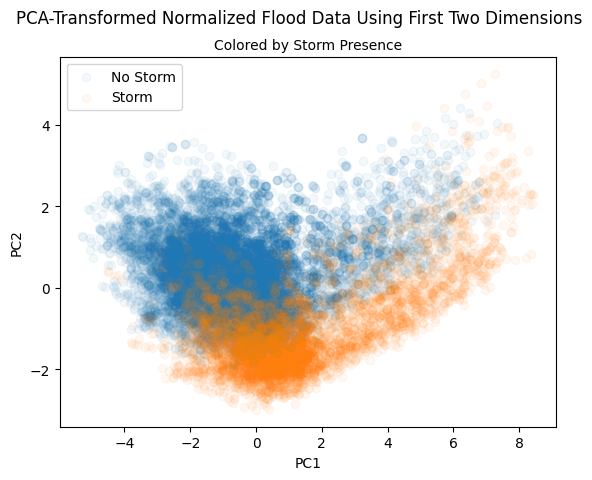

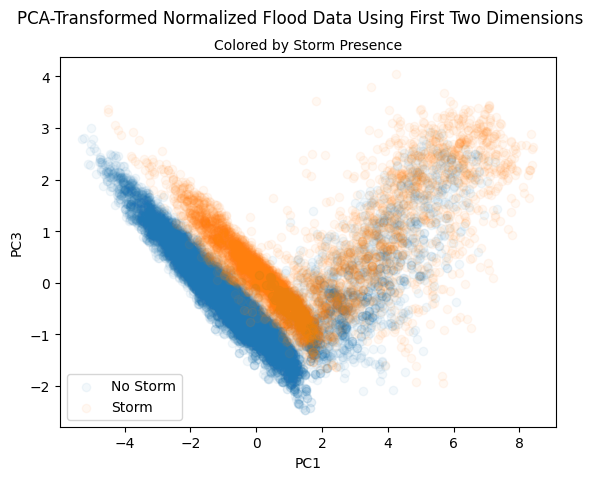

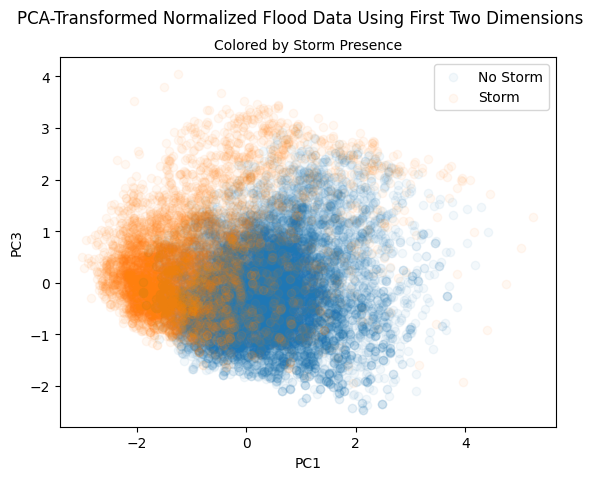

In [19]:
# standardize to zero mean and unit variance
# required before PCA so features on different scales contribute equally
scaler = StandardScaler()
D_scaled = scaler.fit_transform(D)

# run PCA on all components (we will pick how many to keep after inspection)
pca_D_scaled = PCA()
pca_transformed_D_scaled = pca_D_scaled.fit_transform(D_scaled)

# store variance explained per component
explained_var = pca_D_scaled.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

In [81]:
# count how many components are needed to reach 90% cumulative variance
total_var = 0
count = 0

while total_var < 0.90:
    total_var += explained_var[count]
    count += 1

print(f"In order to capture at least 90% of the variance, {count} principal components are needed.")

PC1
flow_pct_max                 0.396186
duration_above_90            0.367729
area_above_90                0.358347
rain_3day_max                0.402185
tp_6h_intensity_mm_hr_max    0.372073
api_k_0_90_max               0.415404
storm_min_distance_km       -0.189770
RH2M_max                     0.263519
WS2M_max                     0.034548
Name: 0, dtype: float64

PC2
flow_pct_max                -0.150314
duration_above_90            0.176891
area_above_90                0.224996
rain_3day_max                0.094612
tp_6h_intensity_mm_hr_max    0.221478
api_k_0_90_max              -0.169781
storm_min_distance_km        0.473960
RH2M_max                    -0.268764
WS2M_max                     0.715396
Name: 1, dtype: float64

PC3
flow_pct_max                -0.297785
duration_above_90            0.509110
area_above_90                0.528543
rain_3day_max               -0.250798
tp_6h_intensity_mm_hr_max   -0.219155
api_k_0_90_max              -0.093161
storm_min_distance_km     

In [84]:
# fraction of variance explained by just the first two components
var_components_1_2 = explained_var[0] + explained_var[1]
print(f"The fraction of variance captured by PC1 and PC2 is {round(var_components_1_2, 4)}.")

----PC1: Top 5 features ---
api_k_0_90_max               0.415404
rain_3day_max                0.402185
flow_pct_max                 0.396186
tp_6h_intensity_mm_hr_max    0.372073
duration_above_90            0.367729

----PC2: Top 5 features ---
WS2M_max                     0.715396
storm_min_distance_km        0.473960
RH2M_max                     0.268764
area_above_90                0.224996
tp_6h_intensity_mm_hr_max    0.221478

----PC3: Top 5 features ---
area_above_90            0.528543
duration_above_90        0.509110
RH2M_max                 0.341594
storm_min_distance_km    0.312462
flow_pct_max             0.297785



## Clustering

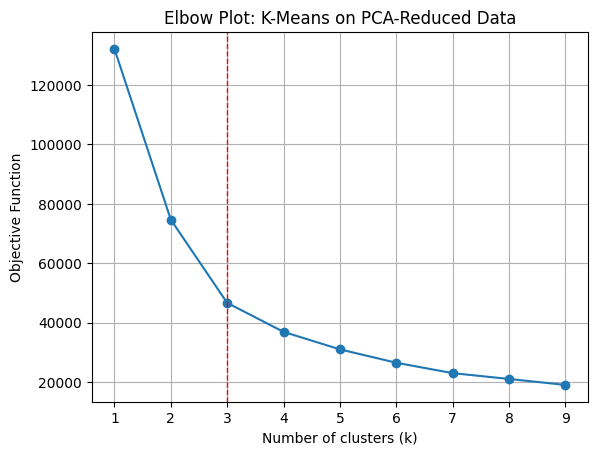

In [88]:
print(explained_var)

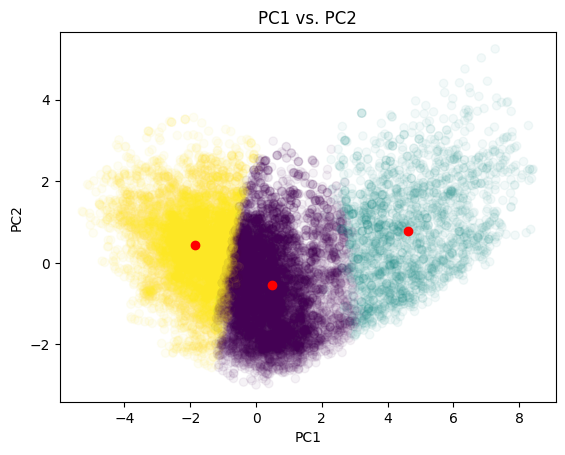

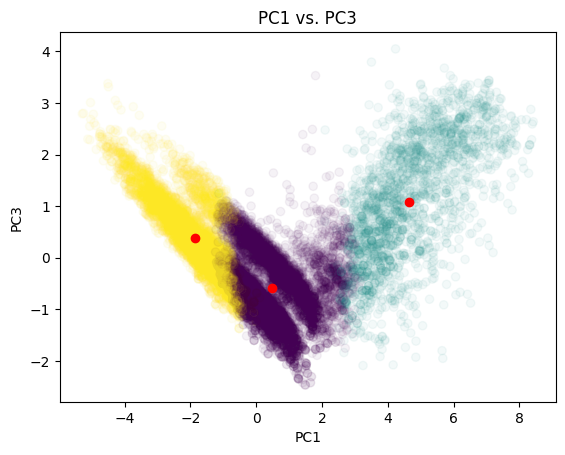

,impact_proxy,is_flood_event
cluster,,
0,38267.564886,0.009033
1,154018.863666,0.110479
2,23539.551753,0.003578


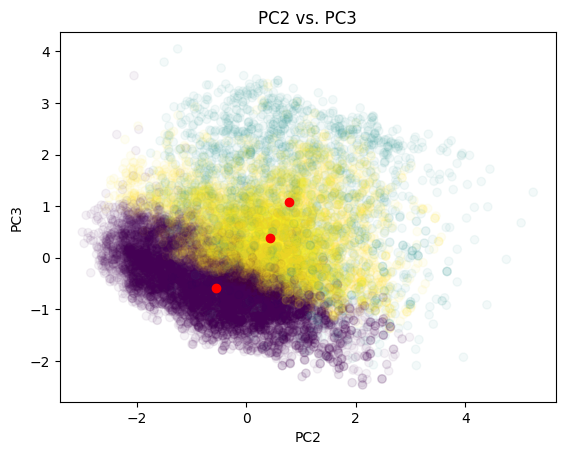

In [22]:
# PLOT CAPTURED VARIANCE
# cumulative plot shows the 90% threshold knee
components = np.arange(1, len(cumulative_var) + 1)

plt.plot(components, cumulative_var, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title("PCA of Flood-Related Features", fontsize = 10)
plt.suptitle('Cumulative Explained Variance by Principal Components')
plt.grid()

# per-component plot shows the drop-off (scree plot)
plt.show()
plt.plot(components, explained_var, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance')
plt.suptitle('Explained Variance by Principal Component')
plt.title("PCA of Flood-Related Features", fontsize = 10)
plt.grid()

In [23]:
# PLOT PCA COMPONENTS
# bring back label columns for coloring (not used in PCA itself)
plot_df = D.copy()
plot_df["no_storm"] = D_raw["no_storm"].values
plot_df["is_flood_event"] = df["is_flood_event"]
plot_df["impact_proxy"] = df["impact_proxy"]
sizes = (plot_df["impact_proxy"] / plot_df["impact_proxy"].max()) * 100  # scale point size by impact severity

flood = plot_df["is_flood_event"] == 1
no_flood = plot_df["is_flood_event"] == 0

# PC1 vs. PC2
plt.scatter(pca_transformed_D_scaled[flood, 0], pca_transformed_D_scaled[flood, 1], alpha = 0.3, s = sizes[flood], label = "Flood")
plt.scatter(pca_transformed_D_scaled[no_flood, 0], pca_transformed_D_scaled[no_flood, 1], alpha = 0.05, s = sizes[no_flood], label = "No Flood")
plt.legend()
plt.suptitle('PC1 vs. PC2')
plt.title("Colored by Flood Event, Sized by Impact", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("figure_pc1_2.png", dpi = 300, bbox_inches = "tight")

# PC1 vs. PC3
plt.show()
plt.scatter(pca_transformed_D_scaled[flood, 0], pca_transformed_D_scaled[flood, 2], alpha = 0.3, s = sizes[flood], label = "Flood")
plt.scatter(pca_transformed_D_scaled[no_flood, 0], pca_transformed_D_scaled[no_flood, 2], alpha = 0.05, s = sizes[no_flood], label = "No Flood")
plt.legend()
plt.suptitle('PC1 vs. PC3')
plt.title("Colored by Flood Event, Sized by Impact", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.savefig("figure_pc1_3.png", dpi = 300, bbox_inches = "tight")

# PC2 vs. PC3
plt.show()
plt.scatter(pca_transformed_D_scaled[flood, 1], pca_transformed_D_scaled[flood, 2], alpha = 0.3, s = sizes[flood], label = "Flood")
plt.scatter(pca_transformed_D_scaled[no_flood, 1], pca_transformed_D_scaled[no_flood, 2], alpha = 0.05, s = sizes[no_flood], label = "No Flood")
plt.legend()
plt.suptitle('PC2 vs. PC3')
plt.title("Colored by Flood Event, Sized by Impact", fontsize = 10)
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.savefig("figure_pc2_3.png", dpi=300, bbox_inches="tight")

Silhoutte Score: k = 3
0.38023018939724634

Silhoutte Score: k = 2
0.5144188859991242

Silhoutte Score: k = 4
0.3533926615465901



Estimated number of clusters: 4
Estimated number of noise points: 98


Text(0, 0.5, 'PC2')

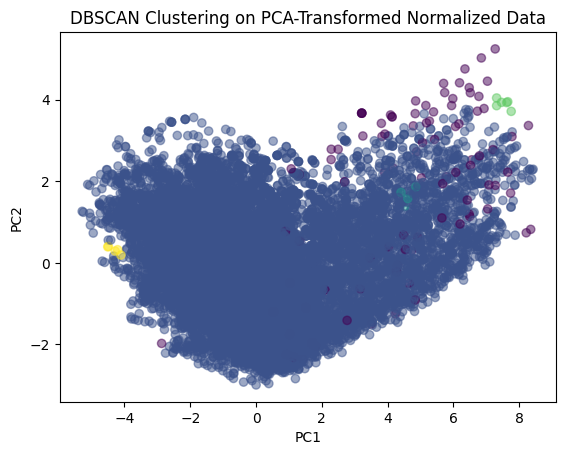

In [24]:
# same PCA plots as above but colored by storm presence
# to see whether storms occupy a distinct region in PC space

# PC1 vs. PC2
plt.show()
no_storm = plot_df["no_storm"] == 1
storm = plot_df["no_storm"] == 0
plt.scatter(pca_transformed_D_scaled[no_storm, 0], pca_transformed_D_scaled[no_storm, 1], alpha = 0.05, label = "No Storm")
plt.scatter(pca_transformed_D_scaled[storm, 0], pca_transformed_D_scaled[storm, 1], alpha = 0.05, label = "Storm")
plt.legend()
plt.suptitle('PCA-Transformed Normalized Flood Data Using First Two Dimensions')
plt.title("Colored by Storm Presence", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("figure_pc1_2_storm.png", dpi = 300, bbox_inches = "tight")

# PC1 vs. PC3
plt.show()
no_storm = plot_df["no_storm"] == 1
storm = plot_df["no_storm"] == 0
plt.scatter(pca_transformed_D_scaled[no_storm, 0], pca_transformed_D_scaled[no_storm, 2], alpha = 0.05, label = "No Storm")
plt.scatter(pca_transformed_D_scaled[storm, 0], pca_transformed_D_scaled[storm, 2], alpha = 0.05, label = "Storm")
plt.legend()
plt.suptitle('PCA-Transformed Normalized Flood Data Using First Two Dimensions')
plt.title("Colored by Storm Presence", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.savefig("figure_pc1_3_storm.png", dpi = 300, bbox_inches = "tight")

# PC2 vs. PC3
plt.show()
no_storm = plot_df["no_storm"] == 1
storm = plot_df["no_storm"] == 0
plt.scatter(pca_transformed_D_scaled[no_storm, 1], pca_transformed_D_scaled[no_storm, 2], alpha = 0.05, label = "No Storm")
plt.scatter(pca_transformed_D_scaled[storm, 1], pca_transformed_D_scaled[storm, 2], alpha = 0.05, label = "Storm")
plt.legend()
plt.suptitle('PCA-Transformed Normalized Flood Data Using First Two Dimensions')
plt.title("Colored by Storm Presence", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.savefig("figure_pc2_3_storm.png", dpi = 300, bbox_inches = "tight")

In [59]:
# VIEW PCA LOADINGS
# each value shows how much a feature contributes to a component
components_pca = pd.DataFrame(pca_D_scaled.components_.T, index = D.columns)

pc1 = components_pca[0]
print("PC1")
print(pc1)
print()

print("PC2")
pc2 = components_pca[1]
print(pc2)
print()

print("PC3")
pc3 = components_pca[2]
print(pc3)
print()


Feature means by cluster (sorted by cross-cluster variation):
                           Cluster 1  Cluster 2  Cluster 3
storm_min_distance_km       9810.521   7251.884  13521.753
api_k_0_90_max                67.958    149.847     29.464
rain_3day_max                 26.874     86.279      9.913
RH2M_max                      85.507     89.291     78.111
duration_above_90              0.185      3.626      0.000
tp_6h_intensity_mm_hr_max      1.368      3.891      0.548
flow_pct_max                   0.728      0.974      0.301
no_storm                       0.593      0.399      0.906
WS2M_max                       2.390      2.880      2.692
area_above_90                  0.004      0.202      0.000


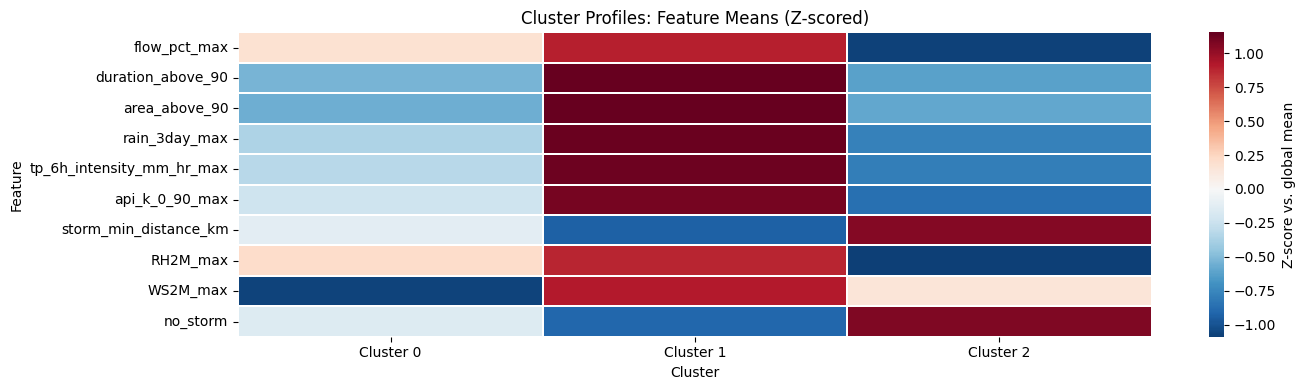

In [86]:
# show the top 5 features by absolute loading for each PC
# what each component represents physically
n_top = 5

pcs = ["PC1", "PC2", "PC3"]

for pc_idx, pc_name in enumerate(pcs):
    loadings = components_pca[pc_idx].abs().sort_values(ascending=False)
    print("----{}: Top {} features ---".format(pc_name, n_top))
    print(loadings.head(n_top).to_string())
    print()

In [87]:
# Which cluster's features explain trigger FNs best?
# Compare FN mean feature profile vs. overall cluster mean
fn_idx = analysis_df[analysis_df["trigger1_case"] == "FN"].index
fn_profile = D_raw.loc[fn_idx].mean()

tp_idx = analysis_df[analysis_df["trigger1_case"] == "TP"].index
tp_profile = D_raw.loc[tp_idx].mean()

comparison = pd.DataFrame({
    "FN": fn_profile,
    "TP": tp_profile,
}).T

# Show top distinguishing features
diff = (comparison.loc["TP"] - comparison.loc["FN"]).abs()
top_diff_cols = diff.sort_values(ascending=False).head(8).index

print("Features where TP and FN differ most:")
print(comparison[top_diff_cols].round(3).to_string())

Features where TP and FN differ most:
    storm_min_distance_km  api_k_0_90_max  rain_3day_max  RH2M_max  duration_above_90  tp_6h_intensity_mm_hr_max  WS2M_max  no_storm
FN               9621.576          89.505         37.810    84.372              1.097                      2.220     2.673     0.604
TP               4163.017         198.842        124.391    91.630              4.310                      4.624     3.352     0.178


## Trigger Evaluation

In [25]:
# K-MEANS: ELBOW PLOT
# use first 3 PCs — captures ~80% of variance with less noise than using all components
D_cluster = pca_transformed_D_scaled[:, :3]
k_values = range(1, 10)
k_obj_pca = []

for k in k_values:
    kmeans = KMeans(n_clusters = k, init = 'k-means++', n_init = 10)
    kmeans.fit(D_cluster)
    k_obj_pca.append(kmeans.inertia_)  # inertia = within-cluster sum of squares

# elbow at k = 3 suggests 3 natural clusters in the data
plt.figure()
plt.plot(k_values, k_obj_pca, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Objective Function')
plt.title('Elbow Plot: K-Means on PCA-Reduced Data')
plt.grid()
plt.axvline(x = 3, linestyle = '--', linewidth = 1, color = "red")
plt.savefig("figure_k_means_elbow.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [73]:
# run K-Means with k = 3 (chosen from elbow plot)
# k-means++ initialization spreads starting centroids to improve convergence
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 0)
pred_cluster_labels = kmeans.fit_predict(D_cluster)
kmeans.cluster_centers_

# plot clusters and centroids across PC pairs
# PC1 vs. PC2
plt.scatter(D_cluster[:,0], D_cluster[:, 1], c=pred_cluster_labels, alpha = 0.05)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c = 'red')
plt.title("PC1 vs. PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("figure_k_means_clustering_pc1_2.png", dpi = 300, bbox_inches = "tight")

# PC1 vs. PC3
plt.show()
plt.scatter(D_cluster[:,0], D_cluster[:, 2], c=pred_cluster_labels, alpha = 0.05)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 2], c = 'red')
plt.title("PC1 vs. PC3")
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.savefig("figure_k_means_clustering_pc1_3.png", dpi = 300, bbox_inches = "tight")

# PC2 vs. PC3
plt.show()
plt.scatter(D_cluster[:,1], D_cluster[:, 2], c=pred_cluster_labels, alpha = 0.05)
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], c = 'red')
plt.title("PC2 vs. PC3")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.savefig("figure_k_means_clustering_pc2_3.png", dpi = 300, bbox_inches = "tight")

# summarize flood rate and mean impact per cluster
plot_df["cluster"] = pred_cluster_labels
plot_df.groupby("cluster")[["impact_proxy", "is_flood_event"]].mean()

In [74]:
# SILHOUETTE SCORES: compare cluster quality for k = 2, 3, 4
# silhouette score near 1 = well-separated clusters; near 0 = overlapping
sil_score = silhouette_score(D_cluster, pred_cluster_labels)
print("Silhoutte Score: k = 3")
print(sil_score)
print()

kmeans2 = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, random_state = 0)
pred_cluster_labels2 = kmeans2.fit_predict(D_cluster)
kmeans2.cluster_centers_
sil_score2 = silhouette_score(D_cluster, pred_cluster_labels2)
print("Silhoutte Score: k = 2")
print(sil_score2)
print()

kmeans4 = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 300, random_state = 0)
pred_cluster_labels4 = kmeans4.fit_predict(D_cluster)
kmeans4.cluster_centers_
sil_score4 = silhouette_score(D_cluster, pred_cluster_labels4)
print("Silhoutte Score: k = 4")
print(sil_score4)
print()

,window_id,center_date,window_start,window_end,window_n_days,is_flood_event,n_flood_days_in_window,days_to_nearest_flood_in_window,flow_raw_max,flow_raw_mean,...,trigger1_case,trigger2_case,api_k_0_90_pct,api_k_0_95_pct,trigger3,trigger4,trigger3_case,trigger4_case,trigger5_case,trigger5
0,W000001,1975-01-04,1975-01-02,1975-01-06,5,0,0,NaN,50.0305,36.84938,...,TN,TN,0.044300,0.000430,0,0,TN,TN,TN,0
1,W000002,1975-01-05,1975-01-03,1975-01-07,5,0,0,NaN,45.3183,34.26694,...,TN,TN,0.044300,0.000430,0,0,TN,TN,TN,0
2,W000003,1975-01-06,1975-01-04,1975-01-08,5,0,0,NaN,45.3183,37.87166,...,TN,TN,0.044300,0.000430,0,0,TN,TN,TN,0
3,W000004,1975-01-07,1975-01-05,1975-01-09,5,0,0,NaN,45.3183,38.02028,...,TN,TN,0.032218,0.000215,0,0,TN,TN,TN,0
4,W000005,1975-01-08,1975-01-06,1975-01-10,5,0,0,NaN,42.1990,34.75174,...,TN,TN,0.024378,0.000107,0,0,TN,TN,TN,0


In [75]:
# DBSCAN: density-based clustering as an alternative to K-Means
# useful here because it can find non-spherical clusters and flag outliers as noise (-1)
db = DBSCAN(eps = 0.5, min_samples = 5)
pred_labels = db.fit_predict(D_cluster)

n_clusters_ = len(set(pred_labels)) - (1 if -1 in pred_labels else 0)
n_noise_ = list(pred_labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.scatter(D_cluster[:,0], D_cluster[:,1], c = pred_labels, alpha = 0.5)
plt.title("DBSCAN Clustering on PCA-Transformed Normalized Data")
plt.xlabel("PC1")
plt.ylabel("PC2")

    trigger   tp    fp   fn     tn  precision    recall        f1
0  trigger1  197   865  144  17417   0.185499  0.577713  0.280827
1  trigger2  247  1779   94  16503   0.121915  0.724340  0.208703
2  trigger3  183   950  158  17332   0.161518  0.536657  0.248304
3  trigger4  211  1679  130  16603   0.111640  0.618768  0.189153


In [29]:
# profile each cluster by mean feature values in the original (untransformed) space
# this makes the cluster descriptions interpretable in real units
profile_df = D_raw.copy()
profile_df["cluster"] = pred_cluster_labels

cluster_profile = profile_df.groupby("cluster").mean().T
cluster_profile.columns = [f"Cluster {i+1}" for i in cluster_profile.columns]

# sort by cross-cluster variation to highlight the most distinguishing features
cluster_profile["variation"] = cluster_profile.std(axis=1)
cluster_profile = cluster_profile.sort_values("variation", ascending=False)

print("Feature means by cluster (sorted by cross-cluster variation):")
print(cluster_profile.drop(columns="variation").round(3).to_string())

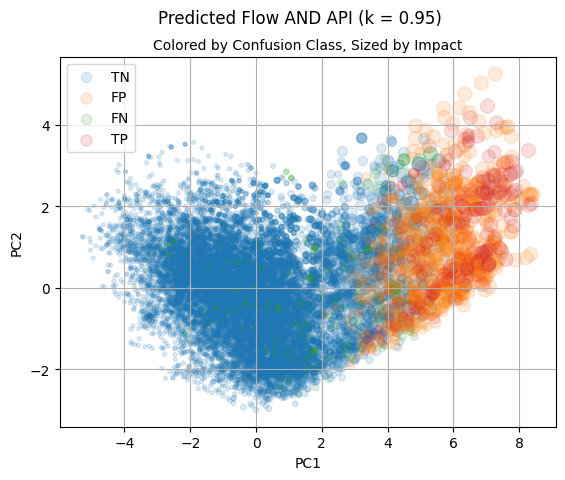

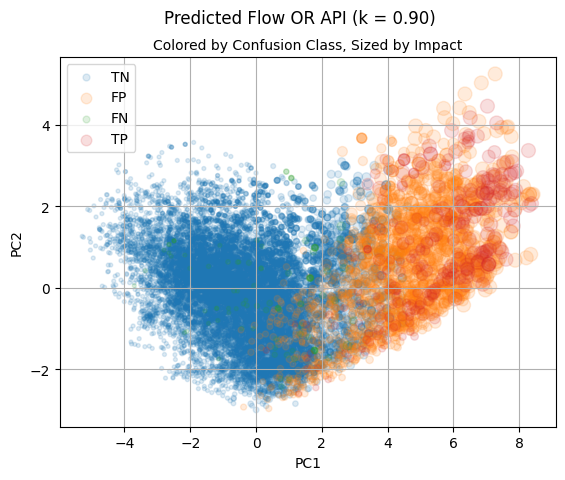

In [48]:
# heatmap of cluster profiles using z-scores so all features are on the same scale
# red = above average, blue = below average relative to global mean
profile_means = profile_df.groupby("cluster").mean()
profile_z = (profile_means - profile_means.mean()) / profile_means.std()
profile_z.index = "Cluster " + profile_z.index.astype(str)

plt.figure(figsize=(14, 4))
sns.heatmap(
    profile_z.T,
    cmap="RdBu_r",
    center=0,
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Z-score vs. global mean"}
)
plt.title("Cluster Profiles: Feature Means (Z-scored)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figure_cluster_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

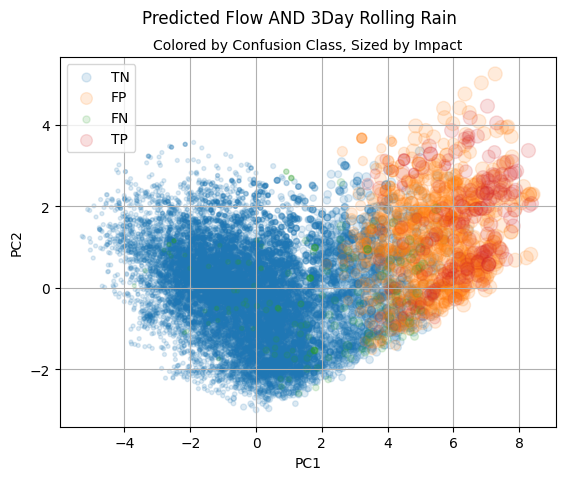

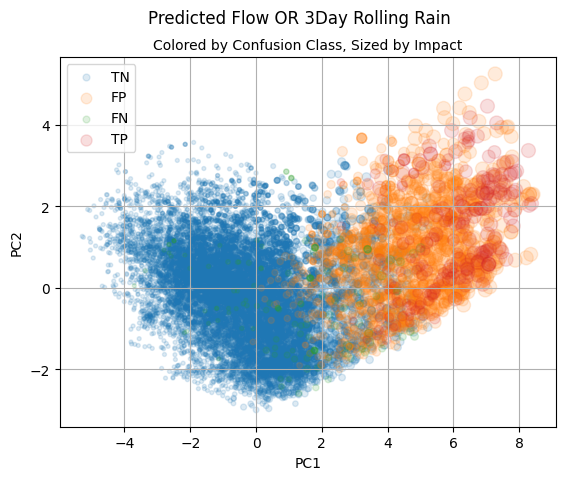

In [49]:
# compare mean feature profiles of FN vs. TP windows
# highlights what conditions the trigger misses vs. correctly catches
fn_idx = analysis_df[analysis_df["trigger1_case"] == "FN"].index
fn_profile = D_raw.loc[fn_idx].mean()

tp_idx = analysis_df[analysis_df["trigger1_case"] == "TP"].index
tp_profile = D_raw.loc[tp_idx].mean()

comparison = pd.DataFrame({
    "FN": fn_profile,
    "TP": tp_profile,
}).T

# top features where TP and FN differ most
diff = (comparison.loc["TP"] - comparison.loc["FN"]).abs()
top_diff_cols = diff.sort_values(ascending=False).head(8).index

print("Features where TP and FN differ most:")
print(comparison[top_diff_cols].round(3).to_string())

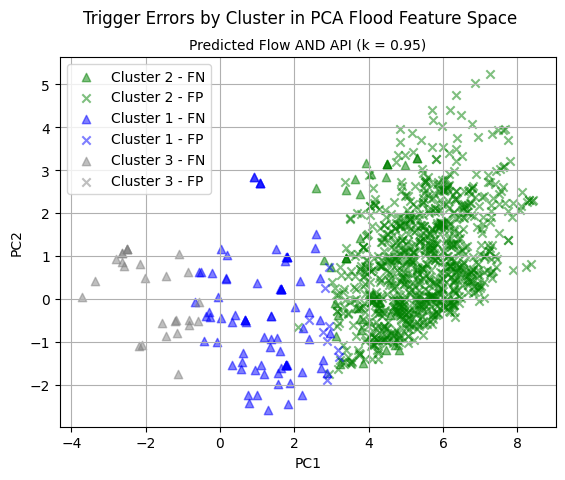

In [50]:
case_col = "trigger1_case"

# only select trigger 1 FP & FN
subset = analysis_df[analysis_df[case_col].isin(["FN", "FP"])].copy()

# color by cluster
cluster_colors = {0: "blue", 1: "green", 2: "gray"}

# Plot errors by cluster
for cluster in subset["cluster"].unique(): # loop through the 3 clusters
    data = subset[subset["cluster"] == cluster] 

    # split clusters by error type
    fn = data[data[case_col] == "FN"]
    fp = data[data[case_col] == "FP"]

    # plot FN - triangle
    plt.scatter(fn["PC1"], fn["PC2"], c = cluster_colors[cluster], marker = "^", 
                alpha = 0.5, label = f"Cluster {cluster + 1} - FN") # account for 0 indexing
    # plot FP - X
    plt.scatter(fp["PC1"], fp["PC2"], c = cluster_colors[cluster], marker = "x", 
                alpha = 0.5, label = f"Cluster {cluster + 1} - FP")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.suptitle("Trigger Errors by Cluster in PCA Flood Feature Space")
plt.title("Predicted Flow AND API (k = 0.95)", fontsize = 10)
plt.grid()
plt.legend()
plt.savefig("figure_pca_clustering_errors.png", dpi = 300, bbox_inches = "tight") # save as png
plt.show()

In [51]:
# merge PCA scores and cluster labels back into the full dataset for analysis
analysis_df = df.copy()

analysis_df["PC1"] = pca_transformed_D_scaled[:, 0]
analysis_df["PC2"] = pca_transformed_D_scaled[:, 1]
analysis_df["PC3"] = pca_transformed_D_scaled[:, 2]
analysis_df["cluster"] = pred_cluster_labels

trigger1_case        FN        FP        TN        TP
cluster                                              
0              0.009033  0.001004  0.989963  0.000000
1              0.017070  0.405880  0.483642  0.093409
2              0.003578  0.000000  0.996422  0.000000


In [52]:
# define 4 flood triggers using different feature combinations and logic
# AND triggers are more conservative (fewer alarms, higher precision)
# OR triggers are more inclusive (more alarms, higher recall)

# Trigger 1: Flow & API (Compound/Balanced)
analysis_df["trigger1"] = ((analysis_df["flow_pct_max"] >= 0.96) & (analysis_df["api_k_0_95_max"].rank(pct=True) >= 0.90)).astype(int)

# Trigger 2: Flow OR API (OR Trigger)
analysis_df["trigger2"] = ((analysis_df["flow_pct_max"] >= 0.975) | (analysis_df["api_k_0_90_max"].rank(pct=True) >= 0.90)).astype(int)

# Trigger 3: Flow AND 3-day Rolling Window Rainfall (Compound/Balanced)
analysis_df["trigger3"] = ((analysis_df["flow_pct_max"] >= 0.975) & (analysis_df["rain_3day_max"].rank(pct=True) >= 0.90)).astype(int)

# Trigger 4: Flow OR 3-day Rolling Window Rainfall (OR Trigger)
analysis_df["trigger4"] = ((analysis_df["flow_pct_max"] >= 0.975) | (analysis_df["rain_3day_max"].rank(pct=True) >= 0.90)).astype(int)

,count,mean,std,min,25%,50%,75%,max
trigger1_case,,,,,,,,
FN,144.0,69412.578018,59272.393879,23095.210633,31245.015368,56747.568273,79922.612599,287335.413966
FP,865.0,189339.408999,72436.195405,91941.128458,118621.106802,176344.551720,287335.413966,287335.413966
TN,17417.0,36065.776255,25374.804230,23095.210633,23095.210633,25353.391130,38387.471926,287335.413966
TP,197.0,221788.882404,70133.071951,96813.806990,156576.363305,247825.901943,287335.413966,287335.413966


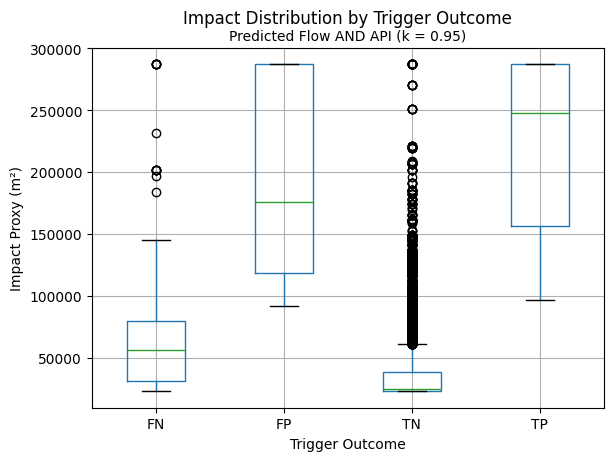

In [53]:
# label each window as TP/TN/FP/FN for each trigger
trigger_cols = ["trigger1", "trigger2", "trigger3", "trigger4"]

for col in trigger_cols:
    case_col = col + "_case"
    analysis_df[case_col] = "TN"  # default: not triggered, not a flood

    analysis_df.loc[(analysis_df[col] == 1) & (analysis_df["is_flood_event"] == 1), case_col] = "TP"
    analysis_df.loc[(analysis_df[col] == 1) & (analysis_df["is_flood_event"] == 0), case_col] = "FP"
    analysis_df.loc[(analysis_df[col] == 0) & (analysis_df["is_flood_event"] == 1), case_col] = "FN"

analysis_df.head()

In [35]:
# compute precision, recall, and F1 for each trigger
# precision = what fraction of alarms are real floods
# recall = what fraction of real floods were caught

summary = []
for col in trigger_cols:
    trigger = analysis_df[col]
    flood = analysis_df["is_flood_event"]

    tp = ((trigger == 1) & (flood == 1)).sum()
    fp = ((trigger == 1) & (flood == 0)).sum()
    fn = ((trigger == 0) & (flood == 1)).sum()
    tn = ((trigger == 0) & (flood == 0)).sum()

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = (2 * precision * recall) / (precision + recall)

    summary.append({"trigger": col,
                    "tp": tp, "fp": fp, "fn": fn, "tn": tn,
                    "precision": precision, "recall": recall, "f1": f1})

summary_df = pd.DataFrame(summary)
print(summary_df)

cluster  trigger1_case
0        FN                52824.567859
         FP               100646.224551
         TN                38071.493558
1        FN               141151.908214
         FP               190271.930798
         TN               110959.933510
         TP               221788.882404
2        FN                23524.168237
         TN                23539.606986
Name: impact_proxy, dtype: float64

In [36]:
case_col = "trigger1_case"

fn_df = analysis_df[analysis_df[case_col] == "FN"]  # missed floods
fp_df = analysis_df[analysis_df[case_col] == "FP"]  # false alarms
tp_df = analysis_df[analysis_df[case_col] == "TP"]
tn_df = analysis_df[analysis_df[case_col] == "TN"]

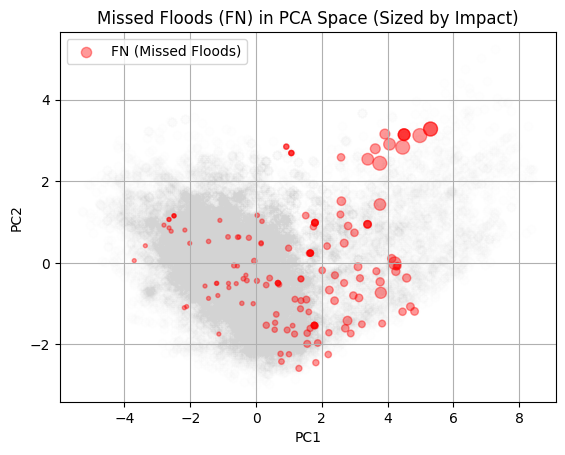

In [54]:
# visualize trigger 1 (Flow AND API) errors in PCA space
# point size = impact severity; helps see if errors cluster around high-impact events
case_col = "trigger1_case"
sizes_impact = (analysis_df["impact_proxy"] / analysis_df["impact_proxy"].max()) * 100

plt.figure()
for case in ["TN", "FP", "FN", "TP"]:
    subset = analysis_df[analysis_df[case_col] == case]
    plt.scatter(subset["PC1"], subset["PC2"], s = sizes_impact[subset.index], alpha = 0.15, label = case)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.suptitle("Predicted Flow AND API (k = 0.95)")
plt.title("Colored by Confusion Class, Sized by Impact", fontsize = 10)
plt.legend()
plt.grid()
plt.savefig("figure_pca_trig1_comparison.png", dpi = 300, bbox_inches = "tight")
plt.show()

# trigger 2 (Flow OR API)
case_col = "trigger2_case"

for case in ["TN", "FP", "FN", "TP"]:
    subset = analysis_df[analysis_df[case_col] == case]
    plt.scatter(subset["PC1"], subset["PC2"], s = sizes_impact[subset.index], alpha = 0.15, label = case)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.suptitle("Predicted Flow OR API (k = 0.90)")
plt.title("Colored by Confusion Class, Sized by Impact", fontsize = 10)
plt.legend()
plt.grid()
plt.savefig("figure_pca_trig2_comparison.png", dpi = 300, bbox_inches = "tight")
plt.show()

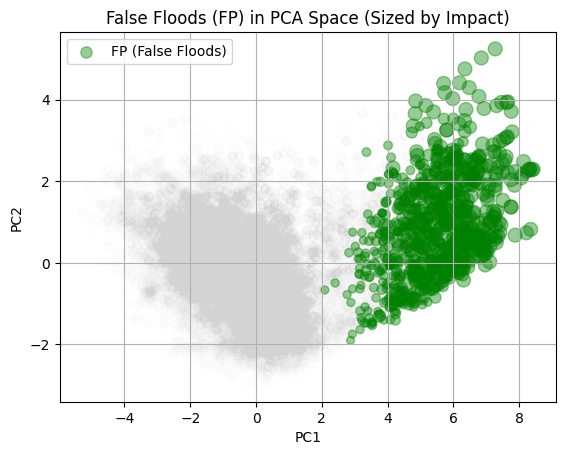

In [55]:
# trigger 3 (Flow AND 3-day rain) and trigger 4 (Flow OR 3-day rain)
case_col = "trigger3_case"
sizes_impact = (analysis_df["impact_proxy"] / analysis_df["impact_proxy"].max()) * 100

plt.figure()
for case in ["TN", "FP", "FN", "TP"]:
    subset = analysis_df[analysis_df[case_col] == case]
    plt.scatter(subset["PC1"], subset["PC2"], s = sizes_impact[subset.index], alpha = 0.15, label = case)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.suptitle("Predicted Flow AND 3Day Rolling Rain")
plt.title("Colored by Confusion Class, Sized by Impact", fontsize = 10)
plt.legend()
plt.grid()
plt.savefig("figure_pca_trig3_comparison.png", dpi = 300, bbox_inches = "tight")
plt.show()

case_col = "trigger4_case"

for case in ["TN", "FP", "FN", "TP"]:
    subset = analysis_df[analysis_df[case_col] == case]
    plt.scatter(subset["PC1"], subset["PC2"], s = sizes_impact[subset.index], alpha = 0.15, label = case)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.suptitle("Predicted Flow OR 3Day Rolling Rain")
plt.title("Colored by Confusion Class, Sized by Impact", fontsize = 10)
plt.legend()
plt.grid()
plt.savefig("figure_pca_trig4_comparison.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [56]:
# plot trigger 1 errors (FP and FN) colored by cluster
# triangles = missed floods (FN), X = false alarms (FP)
# reveals whether errors are concentrated in specific weather regimes
case_col = "trigger1_case"
subset = analysis_df[analysis_df[case_col].isin(["FN", "FP"])].copy()

cluster_colors = {0: "blue", 1: "green", 2: "gray"}

for cluster in subset["cluster"].unique():
    data = subset[subset["cluster"] == cluster]
    fn = data[data[case_col] == "FN"]
    fp = data[data[case_col] == "FP"]

    plt.scatter(fn["PC1"], fn["PC2"], c = cluster_colors[cluster], marker = "^",
                alpha = 0.5, label = f"Cluster {cluster + 1} - FN")
    plt.scatter(fp["PC1"], fp["PC2"], c = cluster_colors[cluster], marker = "x",
                alpha = 0.5, label = f"Cluster {cluster + 1} - FP")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.suptitle("Trigger Errors by Cluster in PCA Flood Feature Space")
plt.title("Predicted Flow AND API (k = 0.95)", fontsize = 10)
plt.grid()
plt.legend()
plt.savefig("figure_pca_clustering_errors.png", dpi = 300, bbox_inches = "tight")
plt.show()

,flow_pct_max,api_k_0_95_pct,PC1,impact_proxy
trigger1_case,,,,
FN,0.771458,0.688830,1.323975,69412.578018
FP,0.984729,0.957038,5.392504,189339.408999
TN,0.556581,0.470419,-0.346664,36065.776255
TP,0.989729,0.973042,6.003440,221788.882404


In [57]:
# proportion of TP/TN/FP/FN within each cluster for trigger 1
# shows whether certain clusters are more error-prone
trigger1_cluster = pd.crosstab(analysis_df["cluster"], analysis_df["trigger1_case"], normalize="index")
print(trigger1_cluster)

,flow_pct_max,api_k_0_95_pct,PC1,impact_proxy
trigger1_case,,,,
FN,0.771458,0.688830,1.323975,69412.578018
FP,0.984729,0.957038,5.392504,189339.408999
TN,0.556581,0.470419,-0.346664,36065.776255
TP,0.989729,0.973042,6.003440,221788.882404
